In [1]:
import numpy as np
import matplotlib.pyplot as plt

Consider the unit disk in 2 dimensions: $$ D = \left\{ (x,y) \in \mathbb{R}^2, \ x^2 + y^2 \leq 1 \right\} $$

The area of the disk is $A = r^2 \pi = \pi$. We can estimate this area using a Monte Carlo simulation.

First, let's plot a quarter of the unit disk, which has area $A/4$.

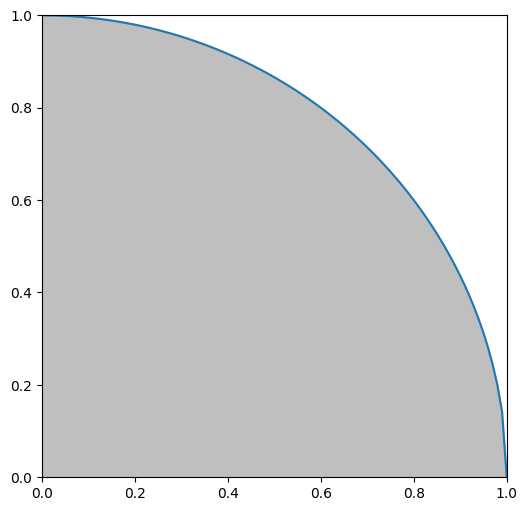

In [2]:


x = np.linspace(0., 1., 100)
y = np.sqrt(1 - x**2)

plt.figure(figsize=(6, 6))
plt.plot(x, y)
# shade area under curve
plt.fill_between(x, y, color='gray', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

## Approach 1

or $x \in [0,1]$, we have 
$$ x^2 + y^2 = 1 \ \Leftrightarrow \ y = \sqrt{1 - x^2}$$

Thus, for $x \in [0,1]$ the circle is just a function $f: [0,1] \to \mathbb{R}$ given by $$ f(x) = \sqrt{1 - x^2} $$

Clearly, $$ \frac{A}{4} = \int_{0}^{1} f(x) \ dx$$

If we could write this as an *expectation* w.r.t. a density we can easily sample from, we could use Monte Carlo simulation to estimate this quantity!

**Important**: Our probability distribution $p$ must satisfy that $p(x) > 0$ whenever $f(x) \neq 0$.

Let $$p(x) = \begin{cases} 1 & x \in [0,1] \\ 0 & \text{otherwise} \end{cases}$$

Then, we have $$ \frac{A}{4} = \int_{0}^{1} f(x) \ dx = \int_{-\infty}^{\infty} f(x) \ p(x) \ dx = \mathbb{E}_{x \sim p(x)} \left[ f(x) \right] $$

And since $p(x)$ is just the uniform distribution on $[0,1]$, we can sample from it easily!

Thus, the Monte Carlo estimate is $$\hat{E}_N^{(1)} = \frac{1}{N} \sum_{i=1}^{N} f(x_i) \approx \frac{A}{4}$$ where $x_i \sim p(x)$ are i.i.d. samples.

In [3]:
def f(x):
    return np.sqrt(1 - x**2)

def pi_monte_carlo_estimate_1(num_samples):
    x_i = np.random.uniform(low=0, high=1, size=num_samples)
    return 4 * np.mean(f(x_i))

np.random.seed(307) # set seed for reproducibility

print(f'True value of pi: {np.pi}')
print('-'*20)
for num_samples in [10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]:
    estimate = pi_monte_carlo_estimate_1(num_samples)
    print(f"Estimate with {num_samples} samples: {estimate}")

True value of pi: 3.141592653589793
--------------------
Estimate with 10000 samples: 3.135222004811579
Estimate with 100000 samples: 3.1428110929963817
Estimate with 1000000 samples: 3.1417652849551794
Estimate with 10000000 samples: 3.1419087019811602
Estimate with 100000000 samples: 3.141498252570656


## Approach 2

We can also write $A/4$ as a double integral:

$$ \frac{A}{4} = \int_0^1 \int_0^1 \mathbf{1} \left[ x^2 + y^2 \leq 1 \right] \, dx \, dy $$

where $\mathbf{1}[\cdot]$ denotes the indicator function.

That is, we integrate over the unit square and only count the points that are inside the unit disk.

We define 

$$p(x,y) = \begin{cases} 1 & \text{if } x \in [0,1] \text{ and } y \in [0,1] \\ 0 & \text{otherwise} \end{cases}$$

which is the uniform distribution on the unit square.

With $g(x,y) = \mathbf{1} \left[ x^2 + y^2 \leq 1 \right]$, we have

$$ \frac{A}{4} = \int_0^1 \int_0^1 g(x,y) \, dx \, dy = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} g(x,y) \, p(x,y) \, dx \, dy = \mathbb{E}_{(x,y) \sim p(x,y)} \left[ g(x,y) \right] $$

Thus, the Monte Carlo estimate is $$\hat{E}_N^{(2)} = \frac{1}{N} \sum_{i=1}^{N} g(x_i, y_i) \approx \frac{A}{4}$$ where $(x_i, y_i) \sim p(x,y)$,  are i.i.d. samples.

In [4]:
def g(x, y):
    return (x**2 + y**2 <= 1).astype(float)

def pi_monte_carlo_estimate_2(num_samples):
    x_i = np.random.uniform(low=0, high=1, size=num_samples)
    y_i = np.random.uniform(low=0, high=1, size=num_samples)

    return 4 * np.mean(g(x_i, y_i))

np.random.seed(307) # set seed for reproducibility

print(f'True value of pi: {np.pi}')
print('-'*20)
for num_samples in [10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]:
    estimate = pi_monte_carlo_estimate_2(num_samples)
    print(f"Estimate with {num_samples} samples: {estimate}")

True value of pi: 3.141592653589793
--------------------
Estimate with 10000 samples: 3.1572
Estimate with 100000 samples: 3.1422
Estimate with 1000000 samples: 3.143012
Estimate with 10000000 samples: 3.1417216
Estimate with 100000000 samples: 3.141336


Is there a difference in these two approaches?